Задача - миинимизация функционала $F(x) = \frac{1}{2} \sum_{i=1}^n r_i^2(x)$,
В коде используется адаптивный чебышёвский алгоритм на основе оценки спектра гессиана.

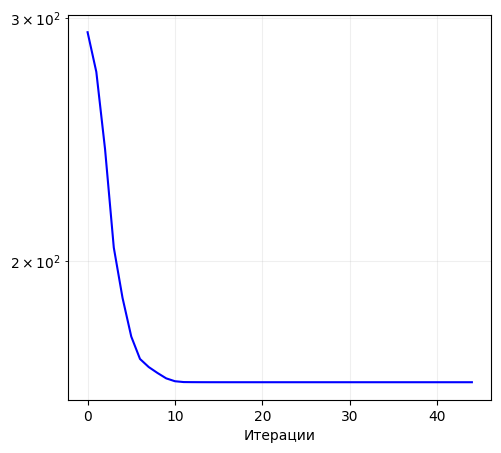

In [4]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
t_data = np.linspace(0, 10, 100)
y_true = 2.5 * np.sin(1.2 * t_data) + 0.5
y_data = y_true + np.random.normal(0, 0.2, size=t_data.shape)

def model(x, t):
    # x[0] = a, x[1] = b, x[2] = c
    return x[0] * np.sin(x[1] * t) + x[2]

def residuals(x):
    return model(x, t_data) - y_data

def objective(x):
    r = residuals(x)
    return 0.5 * np.dot(r, r)

def get_grad(x):
    eps = 1e-7
    n = len(x)
    g = np.zeros(n)
    f0 = objective(x)
    for i in range(n):
        x_plus = x.copy()
        x_plus[i] += eps
        g[i] = (objective(x_plus) - f0) / eps
    return g

def get_hvp(x, v):
    eps = 1e-5
    g0 = get_grad(x)
    g_plus = get_grad(x + eps * v)
    return (g_plus - g0) / eps

def solve_nls_adaptive(x0, iterations=500):
    x = x0.copy()
    n = len(x)
    history = [objective(x)]


    v_max = np.random.randn(n)
    v_max /= np.linalg.norm(v_max)
    v_min = np.random.randn(n)
    v_min /= np.linalg.norm(v_min)

    for it in range(iterations):
        g = get_grad(x)
        if np.linalg.norm(g) < 1e-6:
            break

        # Уточнение спектра (3-4 итерации достаточно)
        for _ in range(3):
            # L (max eigenvalue)
            y_max = get_hvp(x, v_max)
            v_max = y_max / (np.linalg.norm(y_max) + 1e-12)
            lam_max = np.abs(v_max @ y_max)

            # mu (min eigenvalue через сдвиг)
            y_shift = lam_max * v_min - get_hvp(x, v_min)
            v_min = y_shift / (np.linalg.norm(y_shift) + 1e-12)
            sigma = np.abs(v_min @ y_shift)
            lam_min = max(1e-6, np.abs(lam_max - sigma))

        # Шаг
        eta = 2.0 / (lam_max + lam_min)

        x = x - eta * g
        history.append(objective(x))

    return x, history


x0 = np.array([1.0, 2.0, 2.0])
x_opt, hist = solve_nls_adaptive(x0)

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 2)
plt.semilogy(hist, color='blue')
plt.xlabel("Итерации")
plt.grid(True, which="both", ls="-", alpha=0.2)

